<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/11Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Prediction using Decision Tree Classification.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Standard UCI Cleveland Heart Disease URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names based on the standard data dictionary
columns = ['age', 'Gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

# Load data, marking '?' as NaN (missing values)
df = pd.read_csv(url, names=columns, na_values="?")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (303, 14)


,age,Gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   Gender    303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalch    303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,Gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


#EDA

In [ ]:
# Check for missing values
print("Missing values before handling:\n", df.isnull().sum())


Missing values before handling:
 age         0
Gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


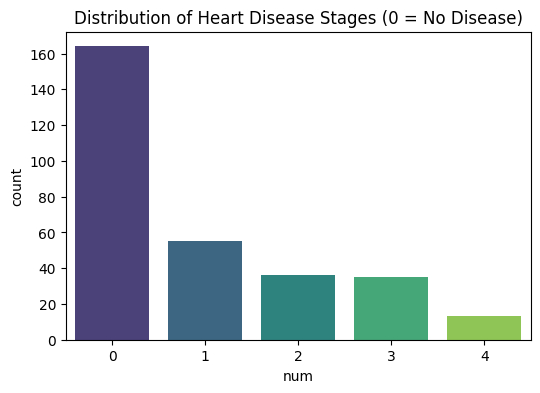

In [ ]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='num', palette='viridis')
plt.title("Distribution of Heart Disease Stages (0 = No Disease)")
plt.show()

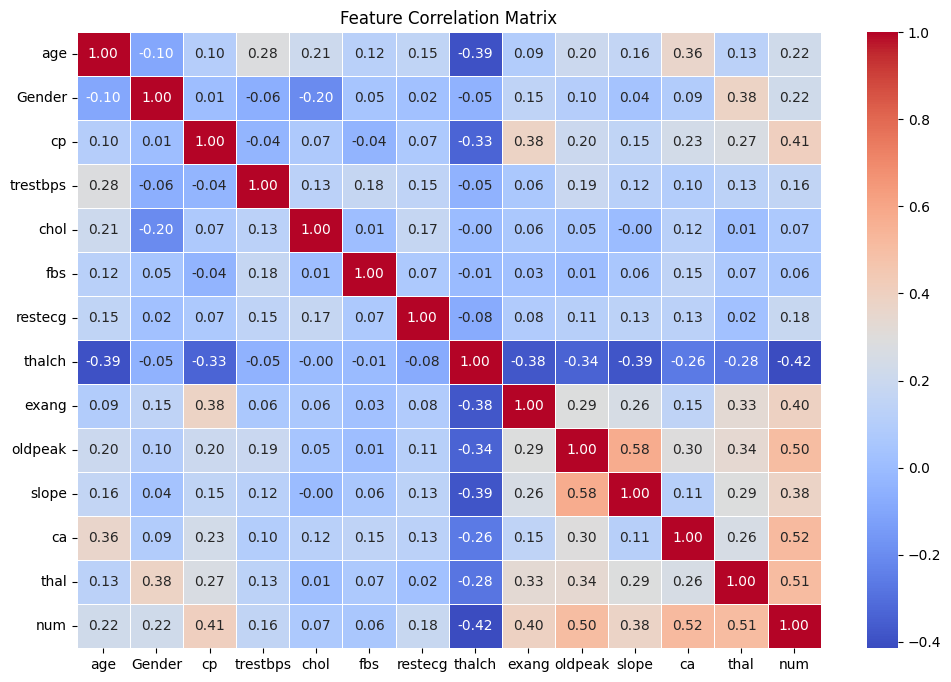

In [ ]:
# Correlation Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
df = df.fillna(df.median())

In [ ]:
df["num"] = df["num"].apply(lambda x:1 if x>0 else 0)

In [ ]:
#define target
X = df .drop("num", axis=1)
y = df["num"]

In [ ]:
print("Features (X) shape:", X.shape[0])
print("Target (y) shape:", y.shape[0])

Features (X) shape: 303
Target (y) shape: 303


#Decision Tree Classification


In [ ]:
# 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train baseline Decision Tree
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# Baseline predictions
y_pred_base = dt_baseline.predict(X_test)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")

Baseline Accuracy: 0.7541


# Hyper parameter tuning

In [ ]:
# Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}

# Set up Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Extract best model
best_dt = grid_search.best_estimator_

print(f"Best Hyperparameters found: {grid_search.best_params_}")

Best Hyperparameters found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 20}


# Model Evaluation  and Analysis

--- Tuned Model Performance ---
Accuracy:  0.8525
Precision: 0.8485
Recall:    0.8750
F1-Score:  0.8615
ROC-AUC:   0.8572

--- Top 5 Important Features ---


,Feature,Importance
2,cp,0.289868
4,chol,0.183771
11,ca,0.173093
0,age,0.141264
12,thal,0.120805


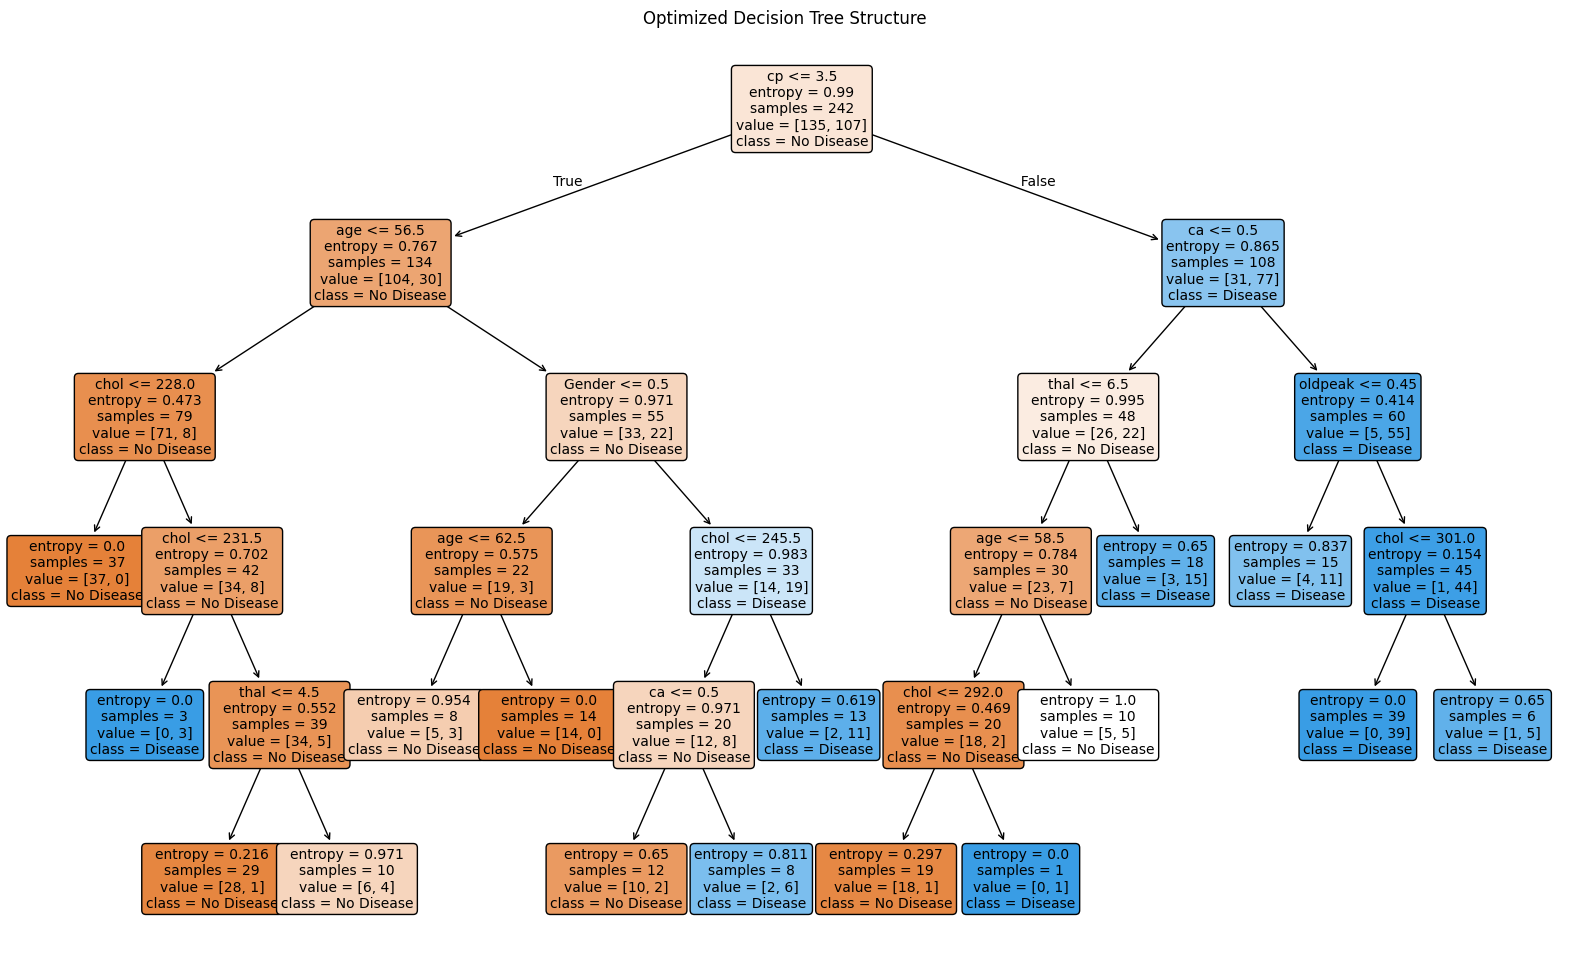

In [ ]:
# Predictions using the tuned model
y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:, 1]

# Print Evaluation Metrics
print("--- Tuned Model Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}\n")

# Feature Importances
importances = best_dt.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("--- Top 5 Important Features ---")
display(feat_imp_df.head(5))

# Visualize the Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(best_dt,
          feature_names=X.columns,
          class_names=['No Disease', 'Disease'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Optimized Decision Tree Structure")
plt.show()


---
## Interview Questions

1.
*   **`max_depth`:** Controls the maximum number of levels in the tree. A higher depth allows the model to learn more complex relationships but easily leads to overfitting. Lowering it acts as regularization.
*   **`min_samples_split`:** The minimum number of data points required in a node before it can be split again. Higher values prevent the tree from learning overly specific, noisy patterns (reduces overfitting).
*   **`criterion`:** The mathematical function used to evaluate the quality of a split. Common options are `gini` (Gini impurity) and `entropy` (Information Gain). They generally perform similarly, though Gini is slightly faster to compute.

2.
*   **Label Encoding:** Converts each unique category into a progressive integer (e.g., Red=0, Blue=1, Green=2). It is highly efficient and ideal for **ordinal** categorical data where a natural ranking exists (e.g., Low, Medium, High). However, if used on non-ordered data, some models might misinterpret the integers as having mathematical weight.
*   **One-Hot Encoding:** Creates a separate binary column (0 or 1) for every unique category in a feature. It is ideal for **nominal** data (no inherent order). The downside is that it expands the feature space significantly (the "curse of dimensionality"), which can increase computational cost and make models sparser.